In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset,ConcatDataset
import numpy as np
import pandas as pd

In [3]:
class CrudeDataset(Dataset):

    mapping = {f"ch{i}": i for i in range(8)}

    def __init__(self, path, seq_len=100):
        self.df = pd.read_csv(path)

        # Ensure correct types early
        self.df["channel"] = self.df["channel"].astype(str)

        # Pre-group for speed + stability
        self.groups = self.df.groupby("batch_id")

        # Keep only valid batch_ids (length >= 2)
        self.batch_ids = [
            bid for bid, g in self.groups
            if len(g) >= 2
        ]

        self.seq_len = seq_len

    def __len__(self):
        return len(self.batch_ids)

    def __getitem__(self, idx):
        batch_id = self.batch_ids[idx]

        # ✅ Safe group access (no copy warning)
        batch_data = self.groups.get_group(batch_id).sort_values("time").copy()

        # =========================
        # Channel mapping (SAFE)
        # =========================
        batch_data["channel"] = batch_data["channel"].map(self.mapping)

        # Fill unmapped channels (important!)
        batch_data["channel"] = batch_data["channel"].fillna(0)

        # =========================
        # TARGET (spoofed)
        # =========================
        target = torch.tensor(
            [float(batch_data.iloc[-1]["spoofed"])],
            dtype=torch.float32
        )

        # =========================
        # DROP UNUSED
        # =========================
        batch_data = batch_data.drop(columns=["spoofed", "time", "batch_id"])

        # Convert to numpy safely
        data = batch_data.to_numpy(dtype=np.float32)

        # =========================
        # SPLIT
        # =========================
        features = data[:-1]           # (T-1, F)
        transformed_target = data[-1]  # (F,)

        # =========================
        # FIX VARIABLE LENGTH (IMPORTANT)
        # =========================
        if len(features) < self.seq_len:
            pad = np.zeros((self.seq_len - len(features), features.shape[1]), dtype=np.float32)
            features = np.vstack([pad, features])
        else:
            features = features[-self.seq_len:]

        # =========================
        # TO TENSOR + CLEAN
        # =========================
        features = torch.from_numpy(features)
        transformed_target = torch.from_numpy(transformed_target)

        # Numerical safety
        features = torch.nan_to_num(features, nan=0.0, posinf=10.0, neginf=-10.0)
        transformed_target = torch.nan_to_num(transformed_target, nan=0.0, posinf=10.0, neginf=-10.0)

        # Clamp (stabilizes training)
        features = torch.clamp(features, -5.0, 5.0)
        transformed_target = torch.clamp(transformed_target, -5.0, 5.0)

        return target, features, transformed_target

In [4]:
train_base="../dataset/train/"
val_base="../dataset/val/"
train_paths=[]
val_paths=[]
for i in range(0,8):
    filename=f"ch{i}.csv"
    train_filepath=train_base+"train_"+filename
    val_filepath=val_base+"val_"+filename
    print(train_filepath)
    print(val_filepath)
    train_paths.append(train_filepath)
    val_paths.append(val_filepath)

../dataset/train/train_ch0.csv
../dataset/val/val_ch0.csv
../dataset/train/train_ch1.csv
../dataset/val/val_ch1.csv
../dataset/train/train_ch2.csv
../dataset/val/val_ch2.csv
../dataset/train/train_ch3.csv
../dataset/val/val_ch3.csv
../dataset/train/train_ch4.csv
../dataset/val/val_ch4.csv
../dataset/train/train_ch5.csv
../dataset/val/val_ch5.csv
../dataset/train/train_ch6.csv
../dataset/val/val_ch6.csv
../dataset/train/train_ch7.csv
../dataset/val/val_ch7.csv


In [5]:
combined_val_dataset = []
combined_train_dataset = []

for train_paths, val_paths in zip(train_paths, val_paths):
    train_dataset=CrudeDataset(train_paths)
    val_dataset=CrudeDataset(val_paths)
    combined_train_dataset.append(train_dataset)
    combined_val_dataset.append(val_dataset)

In [6]:
combined_val_dataset = ConcatDataset(combined_val_dataset)
combined_train_dataset = ConcatDataset(combined_train_dataset)

In [7]:
train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(combined_val_dataset, batch_size=32, shuffle=False)

In [8]:
target, features, transformed_target = next(iter(train_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)

Target shape: torch.Size([32, 1])
Features shape: torch.Size([32, 100, 14])
Transformed Target shape: torch.Size([32, 14])


In [9]:
print("features:", features[0][99])

features: tensor([0., 0., 0., 0., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1,):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
                
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
                
        # Output layers
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Prediction head
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, input_dim)
        )
        
    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape
        # Reshape for transformer
        outputs= {
            'input': x,
            'projected': None,
            'positional_encoded': None,
            'encoder_outputs': [],
            "before_output_projection": None,
            'final_output': None
        }
        x = x.view(batch_size , seq_len, input_dim)
        
        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)
        outputs['projected'] = x.detach().cpu()
        # Add positional encoding
        x = self.pos_encoder(x)
        outputs['positional_encoded'] = x.detach().cpu()
        
        residual = x[:, -1, :]  # (batch, input_dim)

        # Apply transformer
        x = self.transformer(x)  # (batch, seq_len, d_model)
        outputs['encoder_outputs'] = x.detach().cpu()
        
        # Take last timestep
        x = x[:, -1, :]  # (batch, d_model)
        
        # Reshape back
        x = x.view(batch_size, self.d_model)
        
        # Apply layer norm and residual
        x = self.layer_norm1(x+residual)
        x = self.dropout(x)

        outputs["before_output_projection"] = x.detach().cpu()
        
        # Output projection
        output = self.output_projection(x)
        outputs['final_output'] = output.detach().cpu()
        
        return output, outputs

In [11]:
model_testing = TimeSeriesTransformer(input_dim=features.shape[2])

In [14]:
out,_=model_testing(features)

In [15]:
out.shape

torch.Size([32, 14])

In [16]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Model Parameters: 408782

Starting training...


Epoch 1/30 [Train]:   0%|          | 0/2007 [00:00<?, ?it/s]

Epoch 1/30 [Val]: 100%|██████████| 861/861 [00:31<00:00, 27.11it/s, loss=6.83]


  ✓ Saved best market model (val_loss: 5.108989)

Epoch 1/30
  Train - Market: 6.233522
  Val   - Market: 5.108989
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 2/30 [Val]: 100%|██████████| 861/861 [00:41<00:00, 20.70it/s, loss=4.83]


...

  ✓ Saved best market model (val_loss: 3.745185)

Epoch 28/30
  Train - Market: 3.697044
  Val   - Market: 3.745185
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 29/30 [Val]: 100%|██████████| 861/861 [00:37<00:00, 22.97it/s, loss=4.08]


  ✓ Saved best market model (val_loss: 3.733030)

Epoch 29/30
  Train - Market: 3.695244
  Val   - Market: 3.733030
  LR    - Market: 0.000100
------------------------------------------------------------


Epoch 30/30 [Val]: 100%|██████████| 861/861 [00:37<00:00, 22.96it/s, loss=4.06]


  ✓ Saved best market model (val_loss: 3.731697)

Epoch 30/30
  Train - Market: 3.694598
  Val   - Market: 3.731697
  LR    - Market: 0.000100
------------------------------------------------------------

Training completed!


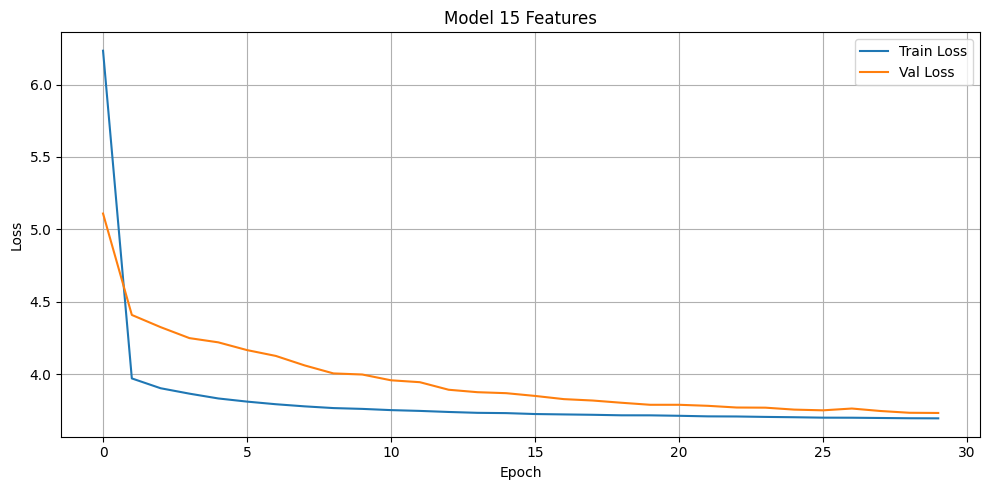

In [19]:
model=TimeSeriesTransformer(input_dim=features.shape[2]).to(device)

print("Model Parameters:", sum(p.numel() for p in model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ==================== TRAINING LOOP ====================

num_epochs = 30
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for _, features, transformed_target in train_bar:
        # Move to device
        features = features.to(device)
        transformed_target = transformed_target.to(device)
        
        # Train Market Model
        optimizer.zero_grad()
        output, _ = model(features)
        loss = criterion(output, transformed_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    model.eval()        
    val_loss = 0
    

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for _, features, transformed_target in val_bar:
            features = features.to(device)
            transformed_target = transformed_target.to(device)

            output,_ = model(features)
            
            loss = criterion(output, transformed_target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save(model.state_dict(), 'best_model_6.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train - Market: {avg_train:.6f}")
    print(f"  Val   - Market: {avg_val:.6f}")
    print(f"  LR    - Market: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 15 Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()


In [20]:
class Head(nn.Module):
    def __init__(
        self,
        dim: int = 18,
        hidden_dim: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)  # (B, 1) → RAW LOGITS

Head Model Parameters: 12473
Timeseries Model Parameters: 408782

Starting training...


Epoch 1/20 [Train]:   0%|          | 0/2007 [00:00<?, ?it/s]

/tmp/ipykernel_4939/3752962797.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)
Epoch 1/20 [Val]:   0%|          | 0/861 [00:00<?, ?it/s]/tmp/ipykernel_4939/3752962797.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)
Epoch 1/20 [Val]: 100%|██████████| 861/861 [00:36<00:00, 23.86it/s, loss=0.648]


  ✓ Saved best market model (val_loss: 0.616085)

Epoch 1/20
  Train - Market: 0.785564
  Val   - Market: 0.616085
  LR    - Market: 0.000050
------------------------------------------------------------


Epoch 2/20 [Val]: 100%|██████████| 861/861 [00:37<00:00, 23.22it/s, loss=0.484]


...


Epoch 18/20
  Train - Market: 0.764214
  Val   - Market: 1.147473
  LR    - Market: 0.000050
------------------------------------------------------------


Epoch 19/20 [Val]: 100%|██████████| 861/861 [00:33<00:00, 25.66it/s, loss=7.24]    



Epoch 19/20
  Train - Market: 0.747127
  Val   - Market: 1.157860
  LR    - Market: 0.000050
------------------------------------------------------------


Epoch 20/20 [Val]: 100%|██████████| 861/861 [00:34<00:00, 24.81it/s, loss=7.7]     



Epoch 20/20
  Train - Market: 0.730425
  Val   - Market: 1.174812
  LR    - Market: 0.000050
------------------------------------------------------------

Training completed!


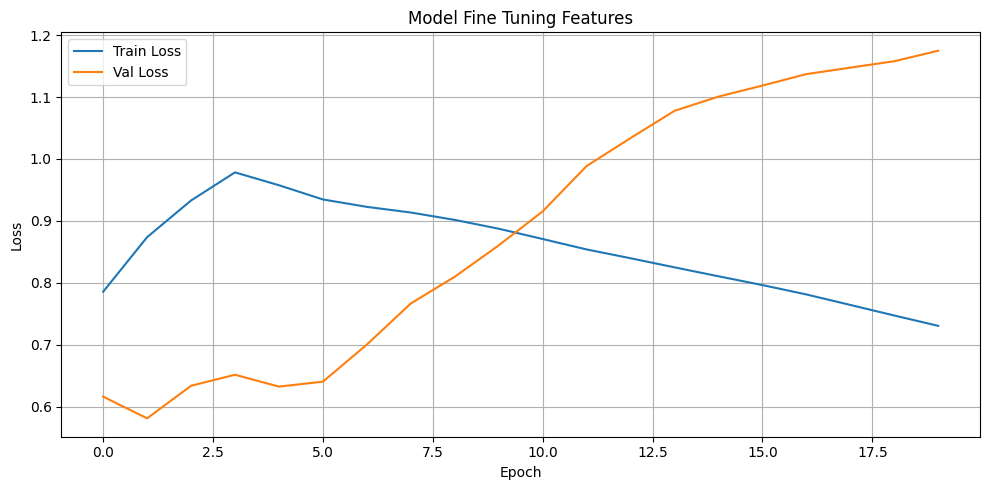

In [22]:
timeseries_model = TimeSeriesTransformer(input_dim=features.shape[2]).to(device)
timeseries_model.load_state_dict(
    torch.load('best_model_6.pth', map_location=device)
)
head_model=Head(28+128).to(device)    
print("Head Model Parameters:", sum(p.numel() for p in head_model.parameters()))
print("Timeseries Model Parameters:", sum(p.numel() for p in timeseries_model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam([
            {'params': head_model.parameters(), 'lr': 0.00005},
            {'params': timeseries_model.parameters(), 'lr': 0.00005 * 0.1},  # Lower LR for pretrained
])

criterion = nn.BCEWithLogitsLoss()
# ==================== TRAINING LOOP ====================

num_epochs = 20
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    timeseries_model.train()
    head_model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for target, features, transformed_target in train_bar:
        # Move to device
        features = features.to(device)
        target = target.to(device)
        transformed_target = transformed_target.to(device)
        
        # Train Market Model
        optimizer.zero_grad()
        output, outputs = timeseries_model(features)
        temp = outputs["before_output_projection"]
        temp = torch.tensor(temp, dtype=torch.float32).to(device)
        fusion = torch.cat([output, transformed_target, temp], dim=-1)
        output = head_model(fusion)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(head_model.parameters()) + list(timeseries_model.parameters()), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    timeseries_model.eval()
    head_model.eval()
    val_loss = 0
    

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for target, features, transformed_target in val_bar:
            features = features.to(device)
            target = target.to(device)
            transformed_target = transformed_target.to(device)

            output, outputs = timeseries_model(features)
            temp = outputs["before_output_projection"]
            temp = torch.tensor(temp, dtype=torch.float32).to(device)
            fusion = torch.cat([output, transformed_target, temp], dim=-1)
            output = head_model(fusion)
            
            loss = criterion(output, target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save({ 'head_model': head_model.state_dict(), 'timeseries_model': timeseries_model.state_dict() }, 'finetuned_with_head.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train - Market: {avg_train:.6f}")
    print(f"  Val   - Market: {avg_val:.6f}")
    print(f"  LR    - Market: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Fine Tuning Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_after_fine_tuning.png')
plt.show()


In [23]:
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,classification_report

In [25]:
timeseries_model.load_state_dict(torch.load('finetuned_with_head.pth')['timeseries_model'])
head_model.load_state_dict(torch.load('finetuned_with_head.pth')['head_model'])

y_pred_list=[]
y_true_list=[]

for target, features, transformed_target in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)

    output,outputs = timeseries_model(features)
    temp = outputs["before_output_projection"]
    temp = torch.tensor(temp, dtype=torch.float32).to(device)
    fusion = torch.cat([output, transformed_target, temp], dim=-1)

    y_pred = head_model(fusion)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)
# If logits → apply sigmoid
y_pred_prob = 1 / (1 + np.exp(-y_pred))  # sigmoid

# Convert to class labels
y_pred_label = (y_pred_prob > 0.5).astype(int)
y_pred_label = y_pred_label.reshape(-1)
y_pred_prob  = y_pred_prob.reshape(-1)
y_true       = y_true.reshape(-1)
print("Accuracy:", accuracy_score(y_true, y_pred_label))
print("Precision:", precision_score(y_true, y_pred_label))
print("Recall:", recall_score(y_true, y_pred_label))
print("F1 Score:", f1_score(y_true, y_pred_label))

# ROC-AUC uses probabilities, NOT labels
print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_label))

/tmp/ipykernel_4939/3273753891.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)


Accuracy: 0.7335464187127706
Precision: 0.7897440519105984
Recall: 0.6365683568211535
F1 Score: 0.7049312203362561
ROC-AUC: 0.7243669770164186

Classification Report:

              precision    recall  f1-score   support

         0.0       0.70      0.83      0.76     13766
         1.0       0.79      0.64      0.70     13766

    accuracy                           0.73     27532
   macro avg       0.74      0.73      0.73     27532
weighted avg       0.74      0.73      0.73     27532



In [26]:
timeseries_model.eval()

X_list = []
y_list = []

with torch.no_grad():
    for target, features, transformed_target in val_loader:

        features = features.to(device)

        # Extract representation
        ts_output, outputs = timeseries_model(features)   # (B, 15)
        temp = outputs["before_output_projection"]
        temp = torch.tensor(temp, dtype=torch.float32).to(device)

        # Choose fusion strategy
        fusion = torch.cat([ts_output, transformed_target.to(device), temp], dim=-1)  # (B, 28)
        # Move to CPU numpy
        X_list.append(fusion.cpu().numpy())
        y_list.append(target.numpy())

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0).reshape(-1)

print("Feature shape:", X.shape)  # (N, 15)
print("Target shape:", y.shape)

/tmp/ipykernel_4939/355361298.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)


Feature shape: (27532, 156)
Target shape: (27532,)


In [27]:
timeseries_model.eval()

X_list_tr = []
y_list_tr = []

with torch.no_grad():
    for target, features, transformed_target in train_loader:

        features = features.to(device)

        # Extract representation
        ts_output, outputs = timeseries_model(features)   # (B, 15)

        # Choose fusion strategy
        temp = outputs["before_output_projection"]
        temp = torch.tensor(temp, dtype=torch.float32).to(device)
        fusion = torch.cat([ts_output, transformed_target.to(device), temp], dim=-1)  # (B, 28)
        # Move to CPU numpy
        X_list_tr.append(fusion.cpu().numpy())
        y_list_tr.append(target.numpy())

X_list_tr = np.concatenate(X_list_tr, axis=0)
y_list_tr = np.concatenate(y_list_tr, axis=0).reshape(-1)

print("Feature shape:", X_list_tr.shape)  # (N, 15)
print("Target shape:", y_list_tr.shape)

/tmp/ipykernel_4939/2451957282.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)


Feature shape: (64214, 156)
Target shape: (64214,)


In [28]:
from xgboost import XGBClassifier

In [29]:
model_xgb = XGBClassifier()
model_xgb.fit(X_list_tr, y_list_tr)
y_pred_xgb = model_xgb.predict(X)
print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("XGBoost Precision:", precision_score(y, y_pred_xgb))
print("XGBoost Recall:", recall_score(y, y_pred_xgb))   
print("XGBoost F1 Score:", f1_score(y, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y, model_xgb.predict_proba(X)[:, 1]) )

print("\nXGBoost Classification Report:\n")
print(classification_report(y, y_pred_xgb))


XGBoost Accuracy: 0.7227226500072643
XGBoost Precision: 0.7261061946902655
XGBoost Recall: 0.7152404474792968
XGBoost F1 Score: 0.7206323647807948
XGBoost ROC-AUC: 0.8427824395334915

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.72      0.73      0.72     13766
         1.0       0.73      0.72      0.72     13766

    accuracy                           0.72     27532
   macro avg       0.72      0.72      0.72     27532
weighted avg       0.72      0.72      0.72     27532



In [30]:
import optuna
import xgboost as xgb
import numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold


def objective(trial, X_list_tr, y_list_tr, n_splits=5):
    """
    Optuna objective: maximise macro-averaged F1 via cross-validation.

    Parameters
    ----------
    trial       : optuna.Trial
    X_list_tr   : array-like, shape (n_samples, n_features)
    y_list_tr   : array-like, shape (n_samples,)  — binary labels {0, 1}
    n_splits    : int, number of CV folds
    """

    # ── Hyperparameter search space ──────────────────────────────────────
    params = {
        # Core booster
        "n_estimators":       trial.suggest_int("n_estimators", 100, 1000, step=50),
        "learning_rate":      trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth":          trial.suggest_int("max_depth", 3, 12),

        # Regularisation
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 10),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "colsample_bylevel":  trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "gamma":              trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        # Fixed settings
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "use_label_encoder":  False,
        "tree_method":        "hist",   # fast; use "gpu_hist" if GPU available
        "random_state":       42,
        "n_jobs":             -1,
    }

    X_arr = np.array(X_list_tr)
    y_arr = np.array(y_list_tr)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_f1_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_arr, y_arr)):
        X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
        y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        y_pred_val = model.predict(X_val)
        fold_f1 = f1_score(y_val, y_pred_val, average="macro")
        fold_f1_scores.append(fold_f1)

        # Pruning: stop unpromising trials early
        trial.report(np.mean(fold_f1_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_f1_scores)


def tune_xgboost(X_list_tr, y_list_tr, n_trials=100, n_splits=5):
    """
    Run Optuna study and return the best XGBClassifier.

    Parameters
    ----------
    X_list_tr   : array-like  — training features
    y_list_tr   : array-like  — training labels (binary)
    n_trials    : int         — number of Optuna trials
    n_splits    : int         — CV folds inside each trial

    Returns
    -------
    best_model  : fitted XGBClassifier with best hyperparameters
    study       : the Optuna study object (for inspection / plots)
    """
    study = optuna.create_study(
        direction="maximize",
        study_name="xgb_f1_optimisation",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
        sampler=optuna.samplers.TPESampler(seed=42),
    )

    study.optimize(
        lambda trial: objective(trial, X_list_tr, y_list_tr, n_splits=n_splits),
        n_trials=n_trials,
        show_progress_bar=True,
    )

    print("\n" + "=" * 55)
    print(f"  Best CV F1 (macro) : {study.best_value:.4f}")
    print(f"  Best trial #       : {study.best_trial.number}")
    print("  Best hyperparams   :")
    for k, v in study.best_params.items():
        print(f"      {k:25s} = {v}")
    print("=" * 55 + "\n")

    # ── Re-train on the full training set with the best params ───────────
    best_params = {
        **study.best_params,
        "objective":          "binary:logistic",
        "eval_metric":        "logloss",
        "use_label_encoder":  False,
        "tree_method":        "hist",
        "random_state":       42,
        "n_jobs":             -1,
    }

    best_model = xgb.XGBClassifier(**best_params)
    best_model.fit(np.array(X_list_tr), np.array(y_list_tr), verbose=False)

    return best_model, study



In [31]:


    # ── Replace your two original lines with these two ───────────────────
model_xgb, study = tune_xgboost(X_list_tr, y_list_tr, n_trials=50)
y_pred_xgb = model_xgb.predict(X)          # X → X_test in demo
# ─────────────────────────────────────────────────────────────────────

print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("XGBoost Precision:", precision_score(y, y_pred_xgb))
print("XGBoost Recall:", recall_score(y, y_pred_xgb))   
print("XGBoost F1 Score:", f1_score(y, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y, model_xgb.predict_proba(X)[:, 1]) )

print("\nXGBoost Classification Report:\n")
print(classification_report(y, y_pred_xgb))


    # Optional: visualise with optuna's built-in plots
    # import optuna.visualization as vis
    # vis.plot_optimization_history(study).show()
    # vis.plot_param_importances(study).show()

[I 2026-04-16 00:44:13,986] A new study created in memory with name: xgb_f1_optimisation


  0%|          | 0/50 [00:00<?, ?it/s]

/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not

[I 2026-04-16 00:44:26,964] Trial 0 finished with value: 0.860844975778552 and parameters: {'n_estimators': 450, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.49359671220172163, 'colsample_bylevel': 0.4348501673009197, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682}. Best is trial 0 with value: 0.860844975778552.


/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [00:44:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not

...

[I 2026-04-16 01:04:57,296] Trial 48 pruned. 


/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:04:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:05:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:05:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-04-16 01:05:14,292] Trial 49 pruned. 

  Best CV F1 (macro) : 0.8648
  Best trial #       : 25
  Best hyperparams   :
      n_estimators              = 200
      learning_rate             = 0.07261314153683482
      max_depth                 = 10
      min_child_weight          = 2
      subsample                 = 0.9638597436441657
      colsample_bytree          = 0.6543996384572474
      colsample_bylevel         = 0.8166577519821002
      gamma                     = 2.2598465227974556
      reg_alpha                 = 0.6660563310264136
      reg_lambda                = 0.004076186980938806



/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:05:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7279166061310475
XGBoost Precision: 0.744868492936861
XGBoost Recall: 0.6933023390963243
XGBoost F1 Score: 0.7181609541367244
XGBoost ROC-AUC: 0.8472479445101051

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.71      0.76      0.74     13766
         1.0       0.74      0.69      0.72     13766

    accuracy                           0.73     27532
   macro avg       0.73      0.73      0.73     27532
weighted avg       0.73      0.73      0.73     27532



In [33]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    # Train on given training data
    model.fit(X_list_tr, y_list_tr)

    # Predict on FULL X (as you requested)
    y_pred = model.predict(X)

    # Optimize F1 score
    f1 = f1_score(y, y_pred)

    return f1


# =========================
# RUN OPTUNA
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, n_jobs=-1)

print("Best F1 Score:", study.best_value)
print("Best Params:", study.best_params)


# =========================
# TRAIN FINAL MODEL
# =========================
best_params = study.best_params

model_xgb = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_list_tr, y_list_tr)

# =========================
# FINAL EVALUATION (your format)
# =========================

y_pred_xgb = model_xgb.predict(X)

print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("XGBoost Precision:", precision_score(y, y_pred_xgb))
print("XGBoost Recall:", recall_score(y, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y, model_xgb.predict_proba(X)[:, 1]))

print("\nXGBoost Classification Report:\n")
print(classification_report(y, y_pred_xgb))

[I 2026-04-16 01:08:30,876] A new study created in memory with name: no-name-e079b1fe-2bf5-4401-bd1d-03addc1c8958
[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[01:08:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder"

Best F1 Score: 0.7454027664768104
Best Params: {'n_estimators': 333, 'max_depth': 3, 'learning_rate': 0.0221721009745792, 'subsample': 0.7278504211411958, 'colsample_bytree': 0.7017750004514547, 'gamma': 3.687415269846868, 'min_child_weight': 4, 'reg_alpha': 0.3300301191023495, 'reg_lambda': 2.948137315140846}


/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:10:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7727008571843673
XGBoost Precision: 0.8471425929350842
XGBoost Recall: 0.6654801685311638
XGBoost F1 Score: 0.7454027664768104
XGBoost ROC-AUC: 0.8428113705111497

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.72      0.88      0.79     13766
         1.0       0.85      0.67      0.75     13766

    accuracy                           0.77     27532
   macro avg       0.79      0.77      0.77     27532
weighted avg       0.79      0.77      0.77     27532

